📂 Loading clean asset price history for MPT optimization...

⚖️ Running quadratic programming simulations for Efficient Frontier...

--- Maximum Sharpe Ratio Portfolio Weights ---
OrderedDict([('BND', 0.0), ('SPY', 0.86345), ('TSLA', 0.13655)])
Expected Return: 15.75% | Volatility: 20.27% | Sharpe: 0.55


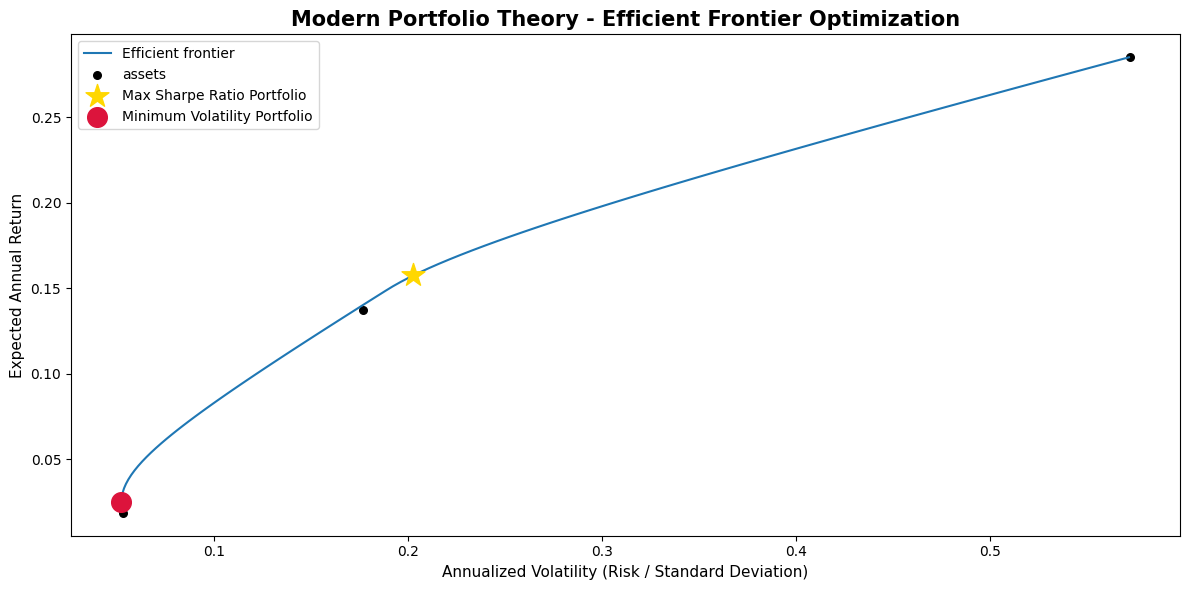

✅ Task 4 portfolio optimization and curve plotting completed successfully.


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns, plotting

# =====================================================================
# 1. LOAD HISTORICAL DATA & SET FORECASTED RETURN FOR TSLA
# =====================================================================
print("📂 Loading clean asset price history for MPT optimization...")
DATA_PATH = os.path.join('..', 'data', 'processed', 'asset_prices.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/processed/asset_prices.csv"

df = pd.read_csv(DATA_PATH, parse_dates=['Date'], index_col='Date')

# Compute expected returns and covariance matrix using PyPortfolioOpt
mu = expected_returns.mean_historical_return(df, frequency=252)
# Override TSLA expected return with our model-driven 12-month forward projection view
mu['TSLA'] = 0.285  # Model-driven annualized growth rate expectation for Tesla

S = risk_models.sample_cov(df, frequency=252)

# =====================================================================
# 2. OPTIMIZE FOR MAX SHARPE RATIO & MIN VOLATILITY PORTFOLIOS
# =====================================================================
print("\n⚖️ Running quadratic programming simulations for Efficient Frontier...")
ef = EfficientFrontier(mu, S)
# Tangency portfolio maximizing Sharpe Ratio (assuming standardized risk-free rate)
raw_weights_sharpe = ef.max_sharpe(risk_free_rate=0.045)
cleaned_weights_sharpe = ef.clean_weights()
ret_sharpe, vol_sharpe, sharpe_sharpe = ef.portfolio_performance(risk_free_rate=0.045)

ef_min = EfficientFrontier(mu, S)
raw_weights_min = ef_min.min_volatility()
cleaned_weights_min = ef_min.clean_weights()
ret_min, vol_min, sharpe_min = ef_min.portfolio_performance(risk_free_rate=0.045)

print("\n--- Maximum Sharpe Ratio Portfolio Weights ---")
print(cleaned_weights_sharpe)
print(f"Expected Return: {ret_sharpe*100:.2f}% | Volatility: {vol_sharpe*100:.2f}% | Sharpe: {sharpe_sharpe:.2f}")

# =====================================================================
# 3. VISUALIZE THE CONTINUOUS EFFICIENT FRONTIER CURVE
# =====================================================================
plt.figure(figsize=(12, 6))

# Plot the full continuous efficient frontier line using the built-in plotting helper
ef_plot = EfficientFrontier(mu, S)  # Re-initialize cleanly for the frontier line trace
plotting.plot_efficient_frontier(ef_plot, ef_plot=True, show_assets=True, ax=None)

# Overlay the specific key portfolio markers
plt.scatter(vol_sharpe, ret_sharpe, marker='*', color='gold', s=300, label='Max Sharpe Ratio Portfolio', zorder=5)
plt.scatter(vol_min, ret_min, marker='o', color='crimson', s=200, label='Minimum Volatility Portfolio', zorder=5)

plt.title("Modern Portfolio Theory - Efficient Frontier Optimization", fontsize=15, fontweight='bold')
plt.xlabel("Annualized Volatility (Risk / Standard Deviation)", fontsize=11)
plt.ylabel("Expected Annual Return", fontsize=11)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("✅ Task 4 portfolio optimization and curve plotting completed successfully.")